## Hands-On Data Preprocessing in Python
Learn how to effectively prepare data for successful data analytics
    
    AUTHOR: Dr. Roy Jafari 

### Chapter 5: Data Visualization 
#### Excercises

In [1]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from ipywidgets import interact, widgets

# Excercise 1
In this exercise, we will be using Universities_imputed_reduced.csv. Draw the following described visualizations.

    a.	Use boxplots to compare the student to faculty ratio (stud./fac. ratio) for the two population public and private universities.
    b.	Use a histogram to compare the student to faculty ratio (stud./fac. ratio) for the two population public and private universities.
    c.	use subplots to put the results of a and b on top of one another to create a visual that compares the two populations even better. 


In [3]:
uni_df = pd.read_csv('Universities_imputed_reduced.csv')
uni_df.head()

,College Name,State,Public/Private,num_appli_rec,num_appl_accepted,num_new_stud_enrolled,in-state tuition,out-of-state tuition,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,Private,193,146,55,7560,7560,76,11.9,15
1,University of Alaska at Fairbanks,AK,Public,1852,1427,928,1742,5226,67,10.0,60
2,University of Alaska Southeast,AK,Public,146,117,89,1742,5226,39,9.5,39
3,University of Alaska at Anchorage,AK,Public,2065,1598,1162,1742,5226,48,13.7,60
4,Alabama Agri. & Mech. Univ.,AL,Public,2817,1920,984,1700,3400,53,14.3,40


a. 

<function matplotlib.pyplot.show(close=None, block=None)>

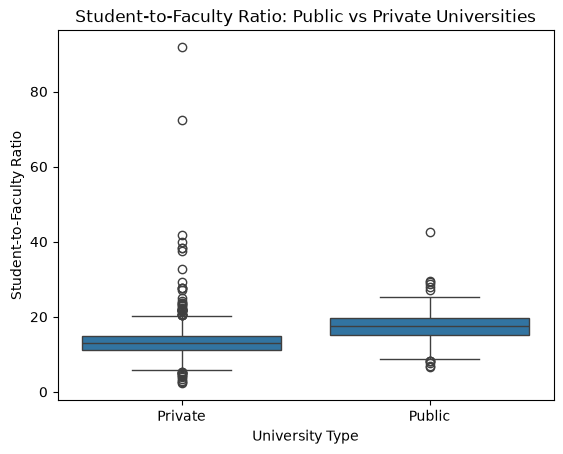

In [4]:
sns.boxplot(
data=uni_df ,
x='Public/Private',
y = 'stud./fac. ratio'
)
plt.title('Student-to-Faculty Ratio: Public vs Private Universities')
plt.xlabel('University Type')
plt.ylabel('Student-to-Faculty Ratio')
plt.show

b. 

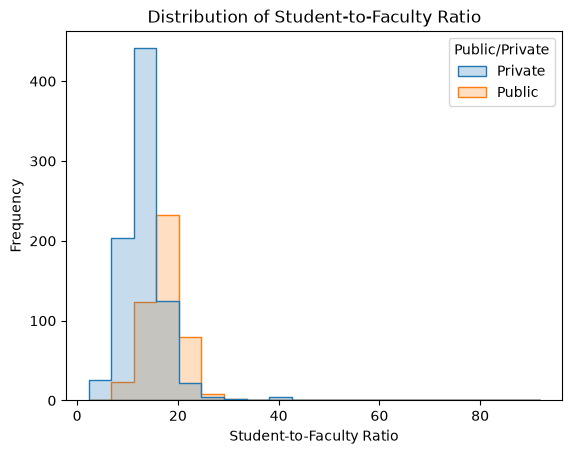

In [5]:
sns.histplot(
    data = uni_df ,
    x = 'stud./fac. ratio',
    hue= 'Public/Private',
     bins=20,
    
    element='step'
)
plt.title('Distribution of Student-to-Faculty Ratio')
plt.xlabel('Student-to-Faculty Ratio')
plt.ylabel('Frequency')
plt.show()

c. 

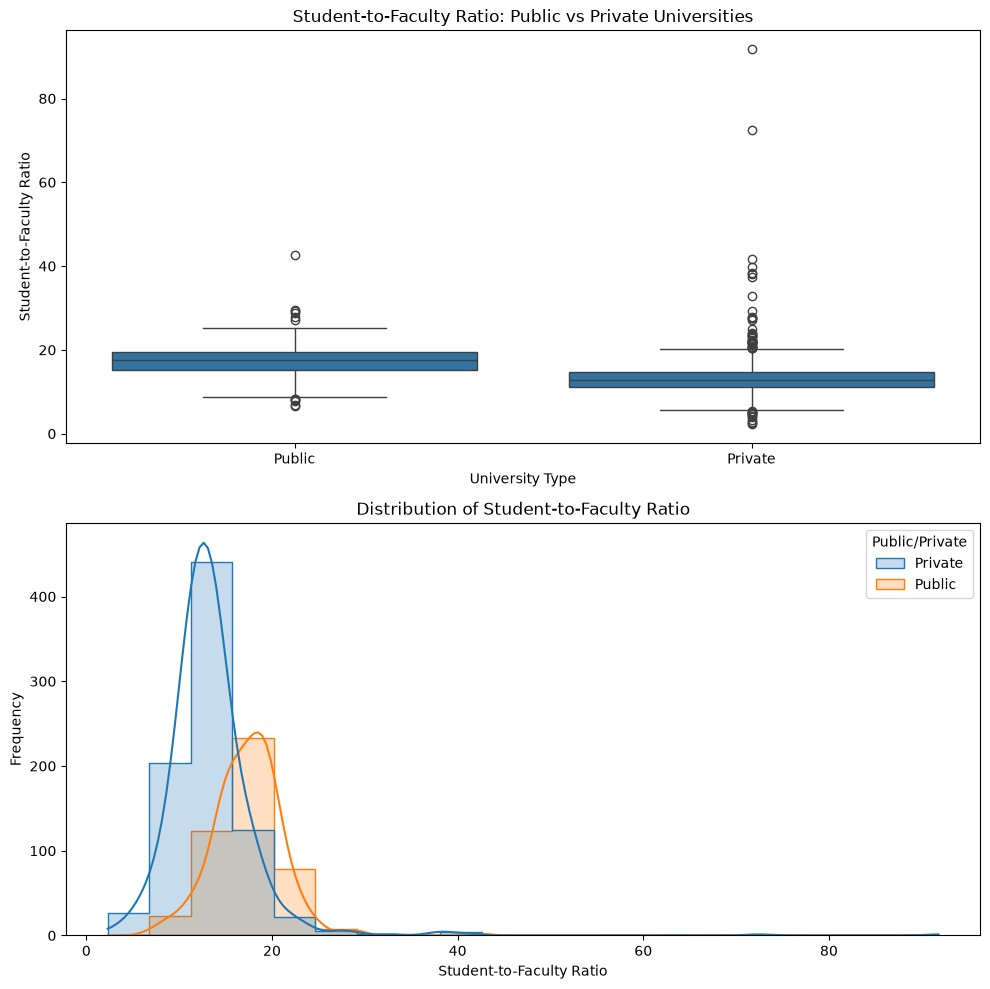

In [6]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 10)
)

# نمودار اول: Boxplot
sns.boxplot(
    data=uni_df,
    x='Public/Private',
    y='stud./fac. ratio',
    order=['Public', 'Private'],
    ax=axes[0]
)

axes[0].set_title(
    'Student-to-Faculty Ratio: Public vs Private Universities'
)
axes[0].set_xlabel('University Type')
axes[0].set_ylabel('Student-to-Faculty Ratio')


# نمودار دوم: Histogram
sns.histplot(
    data=uni_df,
    x='stud./fac. ratio',
    hue='Public/Private',
    bins=20,
    kde=True,
    element='step',
    ax=axes[1]
)

axes[1].set_title(
    'Distribution of Student-to-Faculty Ratio'
)
axes[1].set_xlabel('Student-to-Faculty Ratio')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Excercise 2

In this exercise, we will continue using Universities_imputed_reduced.csv. Draw the following described visualizations.

    a.	Use a bar chart to compare the private/public ratio of all the states in the dataset. In this example, the populations we are comparing are the states. 
    b.	Improve the visualizations by sorting the states on the visuals based on the total number of universities they have.
    c.	Create a stacked bar chart that shows the compare the percentages of public and private schools across different states. 

a.

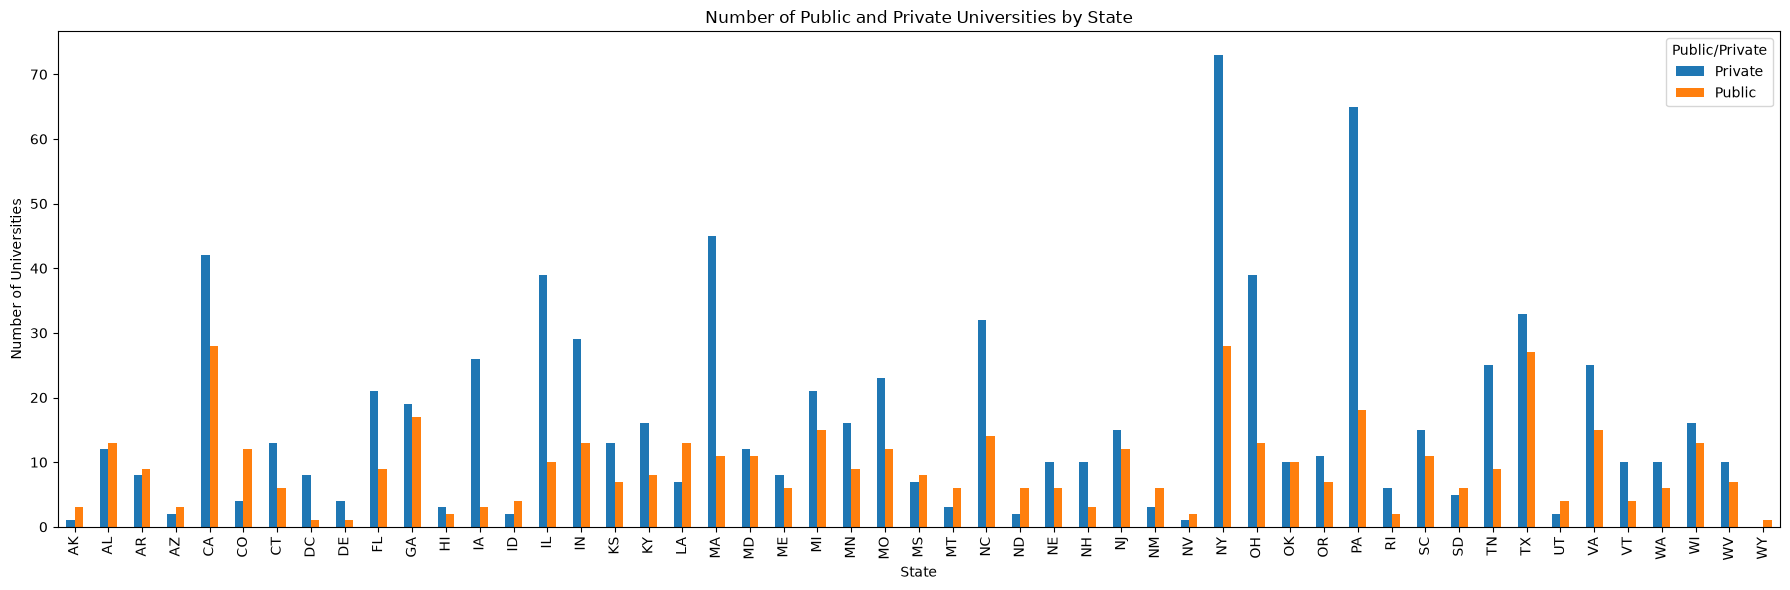

In [7]:
state_counts = pd.crosstab(
    uni_df['State'],
    uni_df['Public/Private']
)

state_counts.plot(
    kind='bar',
    figsize=(18, 6)
)

plt.title('Number of Public and Private Universities by State')
plt.xlabel('State')
plt.ylabel('Number of Universities')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

b.

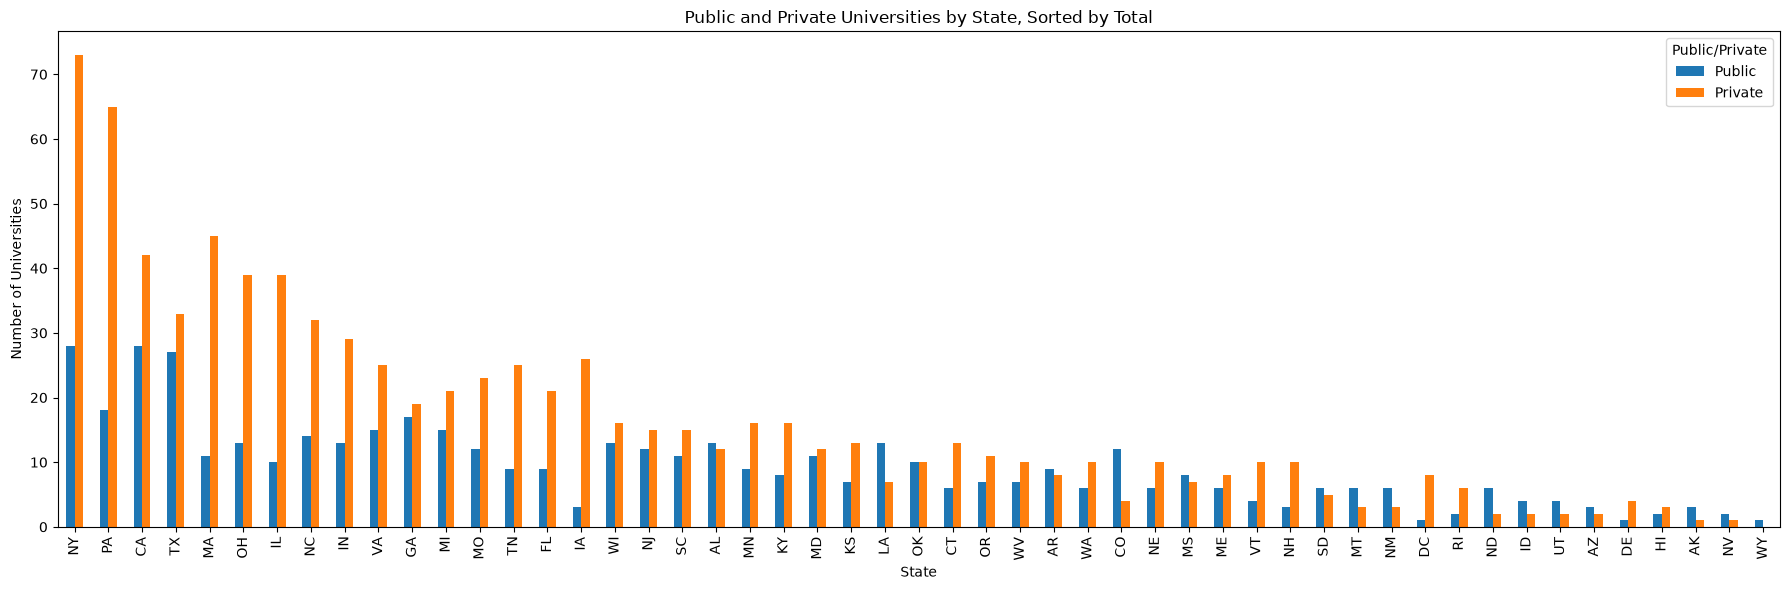

In [8]:
state_counts['Total'] = state_counts.sum(axis=1)

state_counts_sorted = state_counts.sort_values(
    by='Total',
    ascending=False
)

state_counts_sorted[['Public', 'Private']].plot(
    kind='bar',
    figsize=(18, 6)
)

plt.title('Public and Private Universities by State, Sorted by Total')
plt.xlabel('State')
plt.ylabel('Number of Universities')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

c.

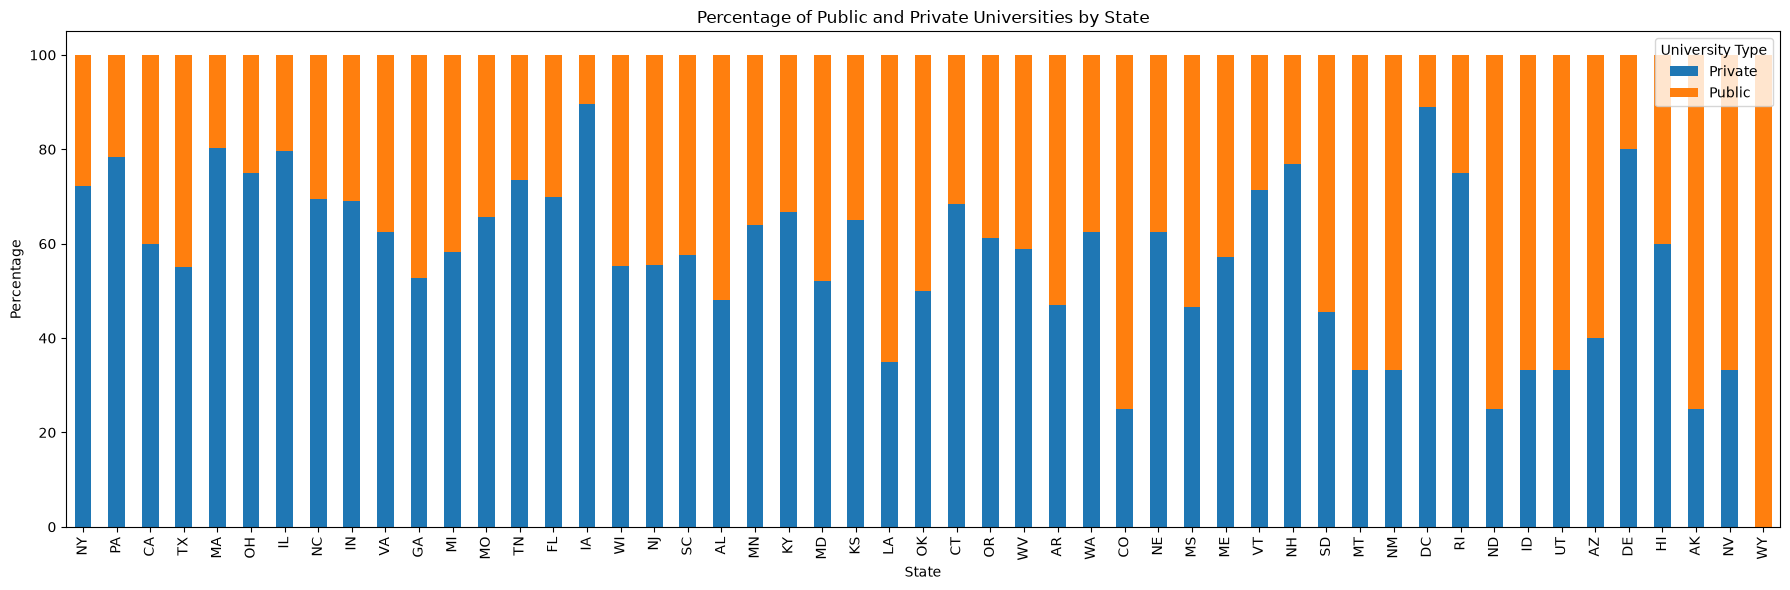

In [9]:
state_percent = pd.crosstab(
    uni_df['State'],
    uni_df['Public/Private'],
    normalize='index'
) * 100

state_percent = state_percent.loc[state_counts_sorted.index]

state_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(18, 6)
)

plt.title('Percentage of Public and Private Universities by State')
plt.xlabel('State')
plt.ylabel('Percentage')
plt.xticks(rotation=90)
plt.legend(title='University Type')
plt.tight_layout()
plt.show()

# Excercise 3

For this example, we will be using WH Report_preprocessed.csv. Draw the following described visualizations.

    a.	Create a visual that compares the relationship between all the happiness indices.
    b.	Use the visual you created in a) to report the happiness indices with strong relationships, and describe those relationships.
    c.	Confirm the relationship you found and described by calculating their correlation coefficients and adding these new pieces of information to your description to improve them. 


In [10]:
report_df = pd.read_csv('WH Report_preprocessed.csv')

a.

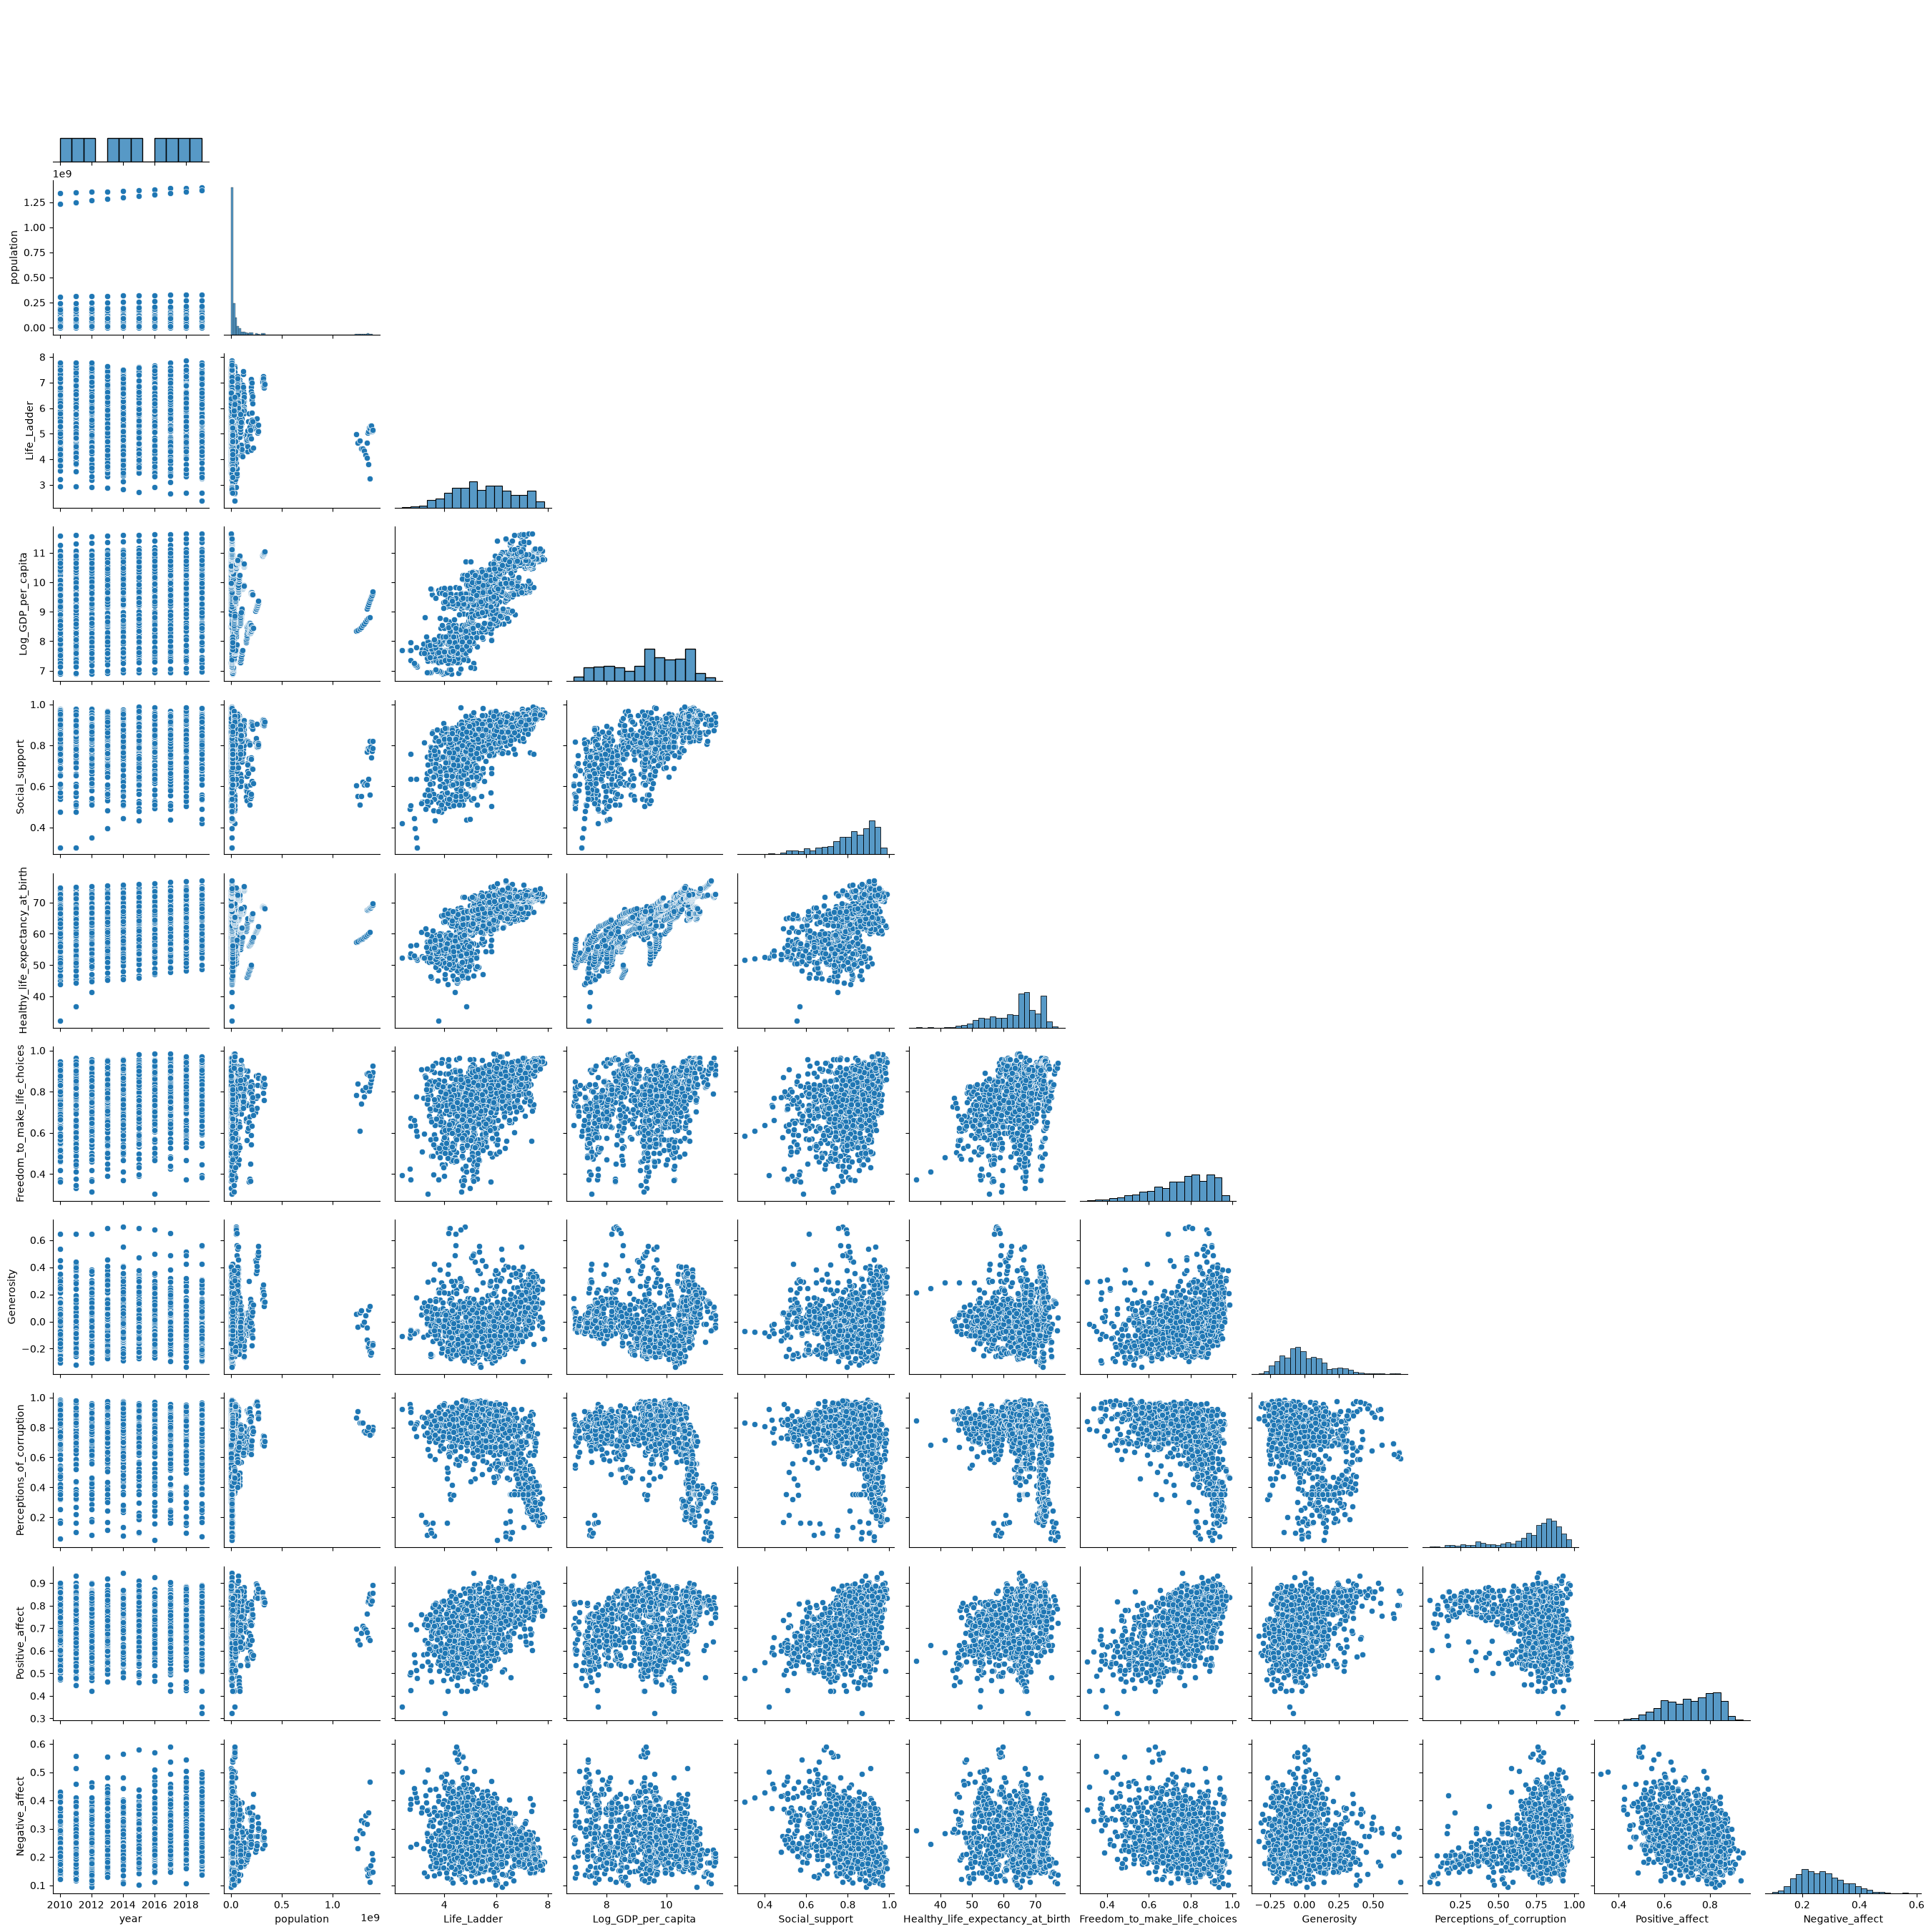

In [11]:
happiness_indices = report_df.select_dtypes(include='number')

happiness_indices = happiness_indices.drop(
    columns=['Year', 'Rank', 'Overall rank'],
    errors='ignore'
)

sns.pairplot(
    happiness_indices,
    corner=True,
    diag_kind='hist'
)

plt.show()

b. 

بر اساس نمودار جفتی، می‌توان چندین رابطه قوی بین شاخص‌های شادی مشاهده کرد. لگاریتم تولید ناخالص داخلی سرانه رابطه مثبت قوی با امید به زندگی سالم دارد، که نشان می‌دهد کشورهایی با سطح درآمد بالاتر عموماً امید به زندگی سالم بالاتری دارند. Life Ladder همچنین روابط مثبتی با لگاریتم تولید ناخالص داخلی سرانه، حمایت اجتماعی و امید به زندگی سالم دارد. این نشان می‌دهد که رفاه اقتصادی، حمایت اجتماعی و شرایط بهداشتی بهتر با ارزیابی‌های بالاتر از زندگی مرتبط هستند.

c.

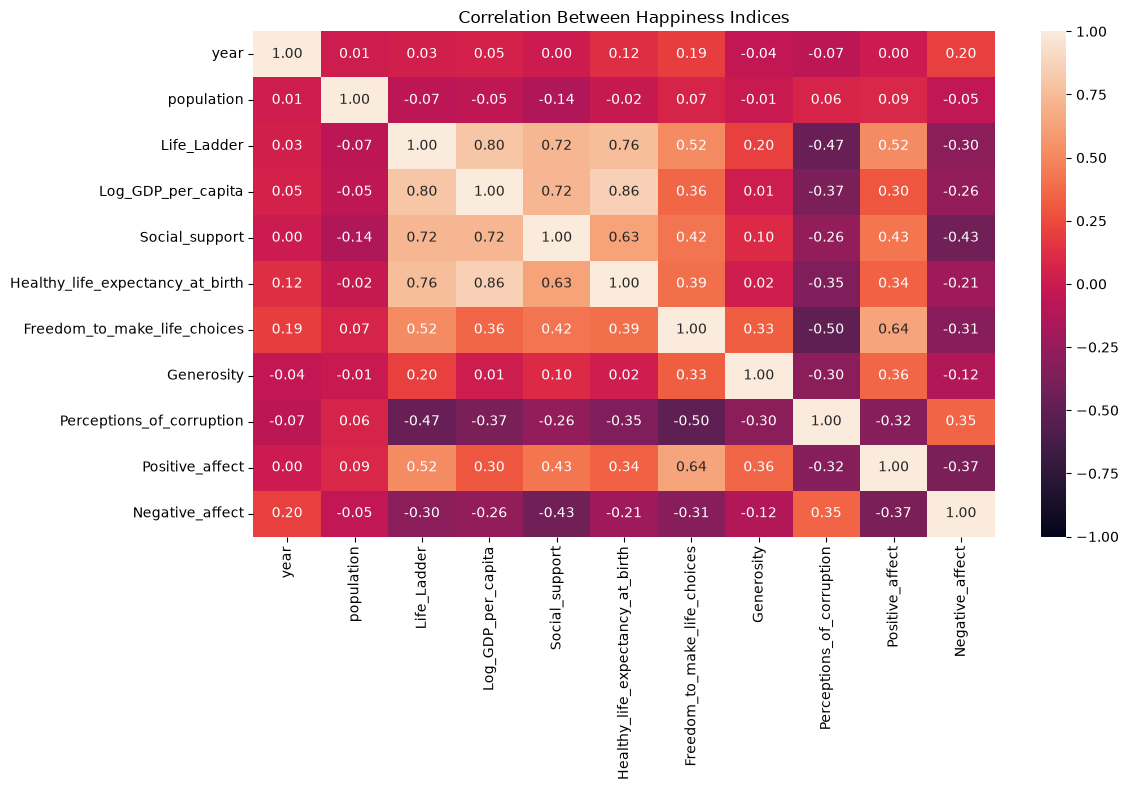

Log_GDP_per_capita            Healthy_life_expectancy_at_birth    0.857981
Life_Ladder                   Log_GDP_per_capita                  0.798912
                              Healthy_life_expectancy_at_birth    0.758287
                              Social_support                      0.723686
Log_GDP_per_capita            Social_support                      0.718969
Freedom_to_make_life_choices  Positive_affect                     0.635665
Social_support                Healthy_life_expectancy_at_birth    0.629507
Life_Ladder                   Freedom_to_make_life_choices        0.518618
                              Positive_affect                     0.518226
Freedom_to_make_life_choices  Perceptions_of_corruption          -0.504291
dtype: float64

In [12]:
correlation_matrix = happiness_indices.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Happiness Indices')
plt.tight_layout()
plt.show()


upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

strongest_relationships = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
)

strongest_relationships.head(10)

# Excercise 4

For this exercise, we will continue using WH Report_preprocessed.csv. Draw the following described visualizations.

    a.	Draw a visual that examine the relationship between the two attributes Continent and Generosity. 
    b.	Based on the visual, is there a relationship between the two attributes? Explain why.

a.

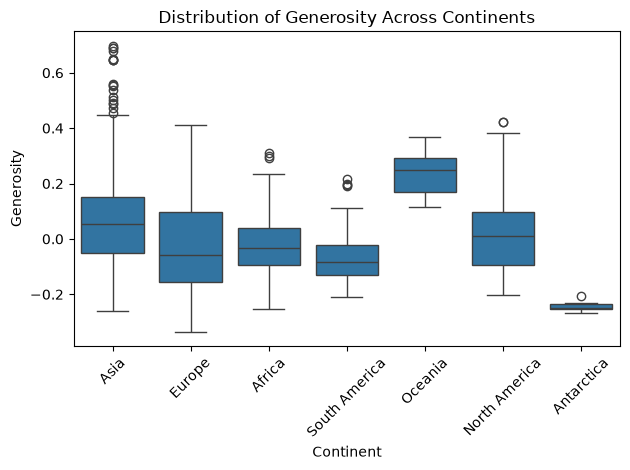

In [13]:
sns.boxplot(
    data=report_df,
    x='Continent',
    y='Generosity'
)

plt.title('Distribution of Generosity Across Continents')
plt.xlabel('Continent')
plt.ylabel('Generosity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

b.

نمودار جعبه‌ای نشان می‌دهد که شاخص سخاوت در قاره‌های مختلف کاملاً یکسان نیست؛ زیرا میانه و توزیع مقادیر بین بعضی قاره‌ها تفاوت دارد. بااین‌حال، هم‌پوشانی قابل‌توجه جعبه‌ها نشان می‌دهد که رابطه میان قاره و سخاوت احتمالاً خیلی قوی نیست.

# Excercise 5

For this exercise, we will be using whickham.csv. Draw the following described visualizations.

    a.	What is the numerical attribute in this dataset? Draw two different plots that summarize the population of data objects for the numerical attribute.
    b.	What are the categorical attributes in this dataset? Draw a plot per attribute that summarizes the population of the data object for each attribute. 
    c.	 Draw a visual that examine the relationship between outcome and smoker. Do you notice anything surprising about this visualization?
    d.	To demystify the surprising relationship you observed on c) run the following code, and study the visual it creates.

``
person_df = pd.read_csv('whickham.csv')
person_df['age_discretized'] = pd.cut(person_df.age, bins = 4, labels=False)
person_df.groupby(['age_discretized','smoker']).outcome.value_counts().unstack().unstack().plot.bar(stacked=True)
plt.show()
``

    e.	Using the visual that was created under d) explain the surprising observation under c).
    f.	How many dimensions the visual that was created under d) has? How did we manage to add dimensions to the bar chart?


In [14]:
person_df = pd.read_csv('whickham.csv')
person_df.head()

,outcome,smoker,age
0,Alive,Yes,23
1,Alive,Yes,18
2,Dead,Yes,71
3,Alive,No,67
4,Alive,No,64


a.

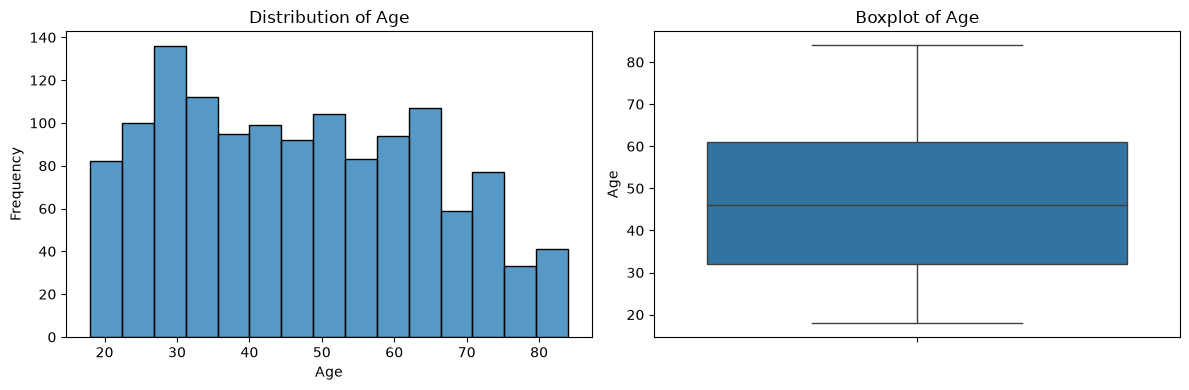

In [17]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4)
)

# Histogram
sns.histplot(
    data=person_df,
    x='age',
    bins=15,
    ax=axes[0]
)

axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')


# Boxplot
sns.boxplot(
    data=person_df,
    y='age',
    ax=axes[1]
)

axes[1].set_title('Boxplot of Age')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

b.

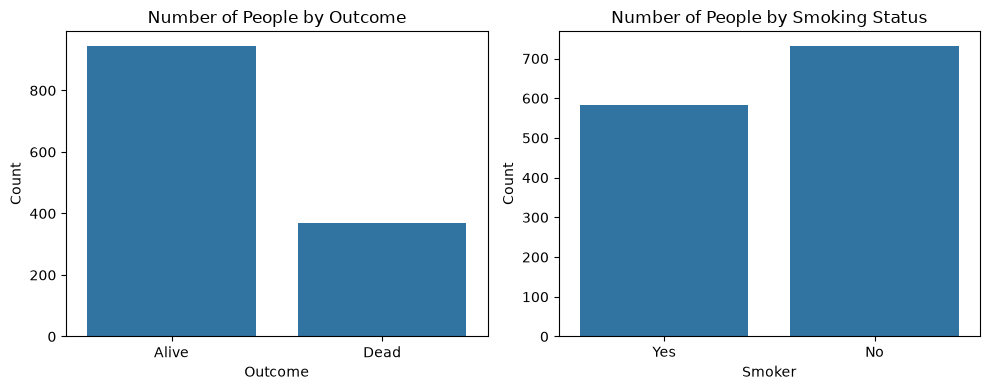

In [18]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 4)
)

sns.countplot(
    data=person_df,
    x='outcome',
    ax=axes[0]
)

axes[0].set_title('Number of People by Outcome')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')


sns.countplot(
    data=person_df,
    x='smoker',
    ax=axes[1]
)

axes[1].set_title('Number of People by Smoking Status')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

c. 

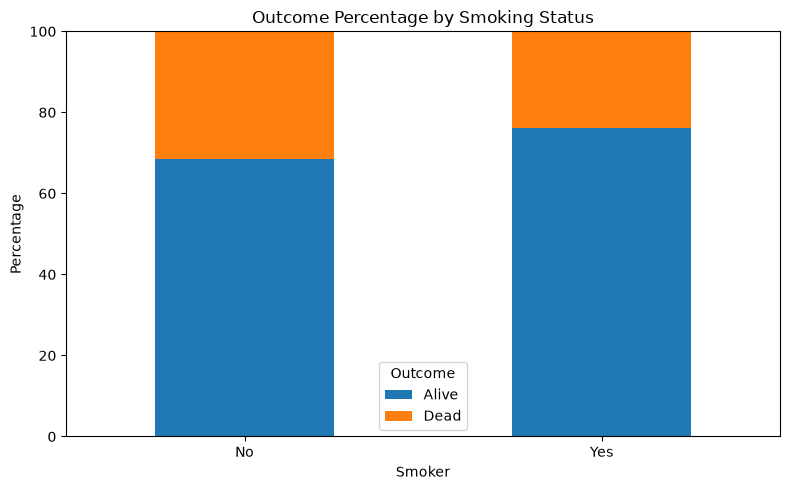

In [19]:
outcome_smoker_percent = pd.crosstab(
    person_df['smoker'],
    person_df['outcome'],
    normalize='index'
) * 100
outcome_smoker_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Outcome Percentage by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

d. 

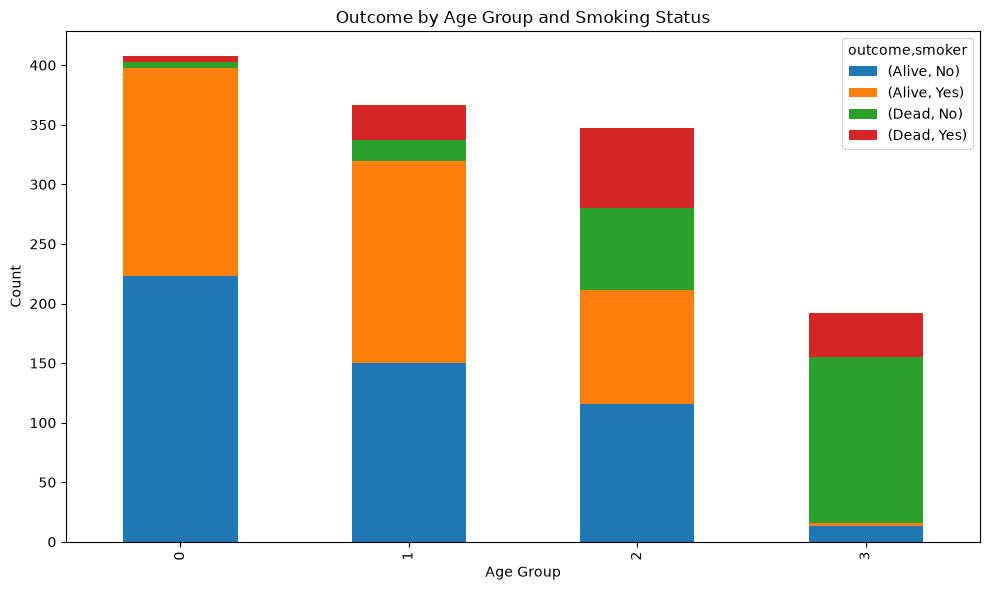

In [20]:
person_df['age_discretized'] = pd.cut(
    person_df['age'],
    bins=4,
    labels=False
)

(
    person_df
    .groupby(['age_discretized', 'smoker'])['outcome']
    .value_counts()
    .unstack()
    .unstack()
    .plot.bar(
        stacked=True,
        figsize=(10, 6)
    )
)

plt.title('Outcome by Age Group and Smoking Status')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

e.

افراد غیرسیگاری این نمونه احتمالاً به‌طور متوسط سن بیشتری دارند. افراد مسن‌تر نیز فارغ از سیگاری‌بودن، احتمال مرگ بیشتری دارند. بنابراین وقتی همه گروه‌های سنی را با هم ترکیب می‌کنیم، افراد غیرسیگاری ظاهراً نرخ مرگ بیشتری نشان می‌دهند.

اما وقتی افراد را در گروه‌های سنی مشابه مقایسه کنیم، مشخص می‌شود که نتیجه اولیه به‌دلیل تفاوت سنی دو گروه گمراه‌کننده بوده است.

این پدیده به نام پارادوکس سیمپسون شناخته می‌شود: رابطه‌ای که در داده‌های کلی مشاهده می‌شود، پس از تقسیم داده‌ها به زیرگروه‌های مناسب ممکن است ضعیف، ناپدید یا حتی معکوس شود.

f.

نمودار سه dimension دسته‌ای و یک measure عددی دارد. سه dimension شامل گروه سنی، وضعیت سیگارکشیدن و پیامد زندگی هستند و measure نیز تعداد افراد است.

# Excercise 6

For this exercise, we will be using WH Report_preprocessed.csv. 

    a.	Use this dataset to create a 5-dimensional scatterplot to show the interactions between the following 5 attributes: year, Healthy_life_expectancy_at_birth, Social_support, Life_Ladder, population. Use the control bar for the “year”, marker size for population, marker color for Social_support, x-axis for Healthy_life_expectancy_at_birth, and y-axis for Life_Ladder.
    b.	Interact with and study the visual you created under a) and report your observations. 



In [15]:
report_df = pd.read_csv('WH Report_preprocessed.csv')

a.

In [ ]:

years = sorted(
    report_df['year']
    .dropna()
    .astype(int)
    .unique()
)


social_min = report_df['Social_support'].min()
social_max = report_df['Social_support'].max()


population_min = report_df['population'].min()
population_max = report_df['population'].max()

x_min = report_df['Healthy_life_expectancy_at_birth'].min()
x_max = report_df['Healthy_life_expectancy_at_birth'].max()

y_min = report_df['Life_Ladder'].min()
y_max = report_df['Life_Ladder'].max()


def draw_happiness_scatter(selected_year):

    # انتخاب اطلاعات مربوط به سال انتخاب‌شده
    year_df = report_df[
        report_df['year'].astype(int) == selected_year
    ].dropna(
        subset=[
            'Healthy_life_expectancy_at_birth',
            'Life_Ladder',
            'Social_support',
            'population'
        ]
    )


    fig, ax = plt.subplots(figsize=(11, 7))

    
    sns.scatterplot(
        data=year_df,

        x='Healthy_life_expectancy_at_birth',
        y='Life_Ladder',

        hue='Social_support',
        size='population',

        hue_norm=(social_min, social_max),
        size_norm=(population_min, population_max),

        sizes=(30, 700),
        alpha=0.7,
        legend='brief',

        ax=ax
    )


    ax.set_xlim(x_min - 2, x_max + 2)
    ax.set_ylim(y_min - 0.5, y_max + 0.5)

    # عنوان‌ها
    ax.set_title(
        f'Happiness Indicators in {selected_year}'
    )

    ax.set_xlabel(
        'Healthy Life Expectancy at Birth'
    )

    ax.set_ylabel(
        'Life Ladder'
    )

    plt.tight_layout()
    plt.show()



interact(
    draw_happiness_scatter,

    selected_year=widgets.SelectionSlider(
        options=years,
        value=years[0],
        description='Year:',
        continuous_update=False
    )
)

b. 

نمودار تعاملی به‌طور کلی رابطه مثبتی میان امید به زندگی سالم و امتیاز ارزیابی زندگی نشان می‌دهد. در بیشتر سال‌ها، کشورهایی که امید به زندگی سالم بیشتری دارند، امتیاز Life Ladder بیشتری نیز ثبت کرده‌اند. رنگ نقاط نیز نشان می‌دهد کشورهایی که حمایت اجتماعی بیشتری دارند، عموماً در قسمت بالاتر نمودار قرار می‌گیرند. بااین‌حال، اندازه نقاط رابطه روشنی میان جمعیت و خوشحالی نشان نمی‌دهد؛ زیرا کشورهای پرجمعیت می‌توانند امتیاز خوشحالی بالا یا پایین داشته باشند. با تغییر سال، موقعیت نقاط تغییر می‌کند، اما الگوی مثبت کلی میان امید به زندگی سالم، حمایت اجتماعی و ارزیابی زندگی همچنان قابل مشاهده است.

# Excercise 7

For this exercise, we will continue using WH Report_preprocessed.csv. 

    a.	Create a visual that shows the trend of change for the attribute Generosity for all the countries in the dataset. To avoid making the visual overwhelming use the color grey for the line plots of all the countries, and don’t use a legend.
    b.	Add three more line plots to the previous visual using the color blue and a thicker line (linewidth=1.8) for the three countries, United States, China, and India. Work out the visual so it only shows you the legend of these three countries. The following screenshot shows the visual that is being described.



Figure 5. 23. Line plot comparing Generosity across all countries in 2010 and 2019 with emphasis on the United States, India, and China


    c.	Report your observations from the visual. Make sure to employ all of the line plots (grey and blue ones) in your observations 

a.

In [22]:
report_df.head()

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
0,Afghanistan,Asia,2010,29185507.0,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
1,Afghanistan,Asia,2011,30117413.0,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
2,Afghanistan,Asia,2012,31161376.0,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
3,Afghanistan,Asia,2013,32269589.0,3.572,7.725,0.484,52.56,0.578,0.061,0.823,0.621,0.273
4,Afghanistan,Asia,2014,33370794.0,3.131,7.718,0.526,52.88,0.509,0.104,0.871,0.532,0.375


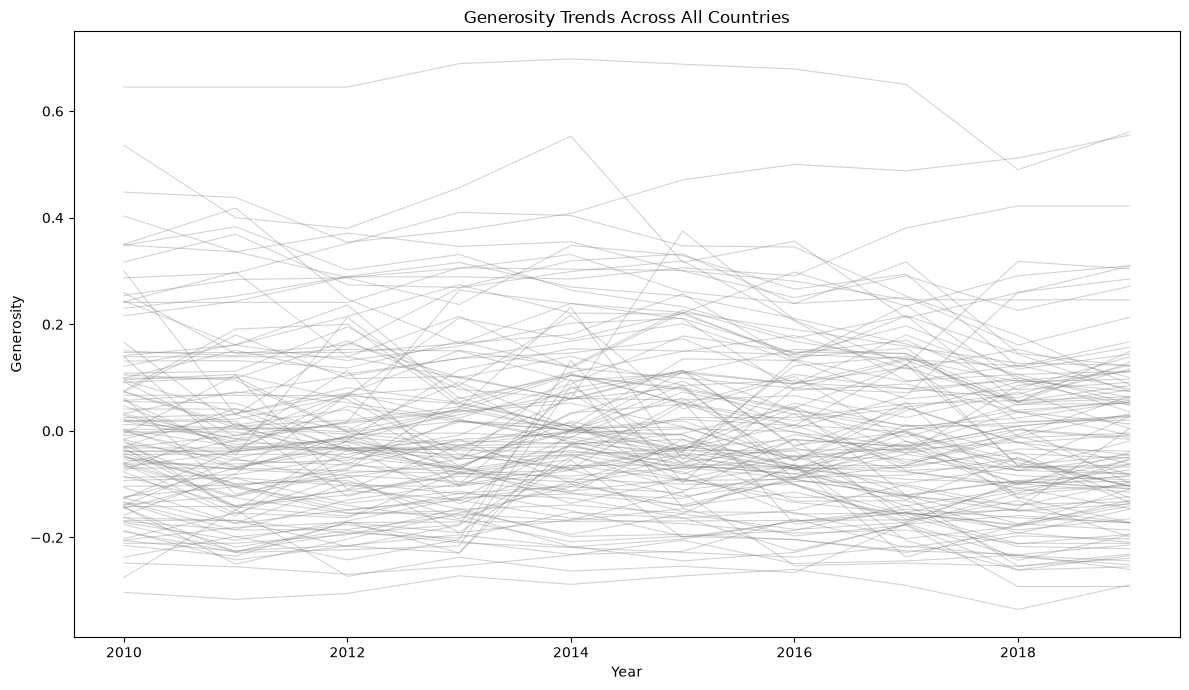

In [23]:

report_sorted = report_df.sort_values(['Name', 'year'])

fig, ax = plt.subplots(figsize=(12, 7))

sns.lineplot(
    data=report_sorted,
    x='year',
    y='Generosity',
    units='Name',
    estimator=None,
    color='grey',
    linewidth=0.8,
    alpha=0.35,
    legend=False,
    ax=ax
)

ax.set_title('Generosity Trends Across All Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Generosity')

plt.tight_layout()
plt.show()

b.

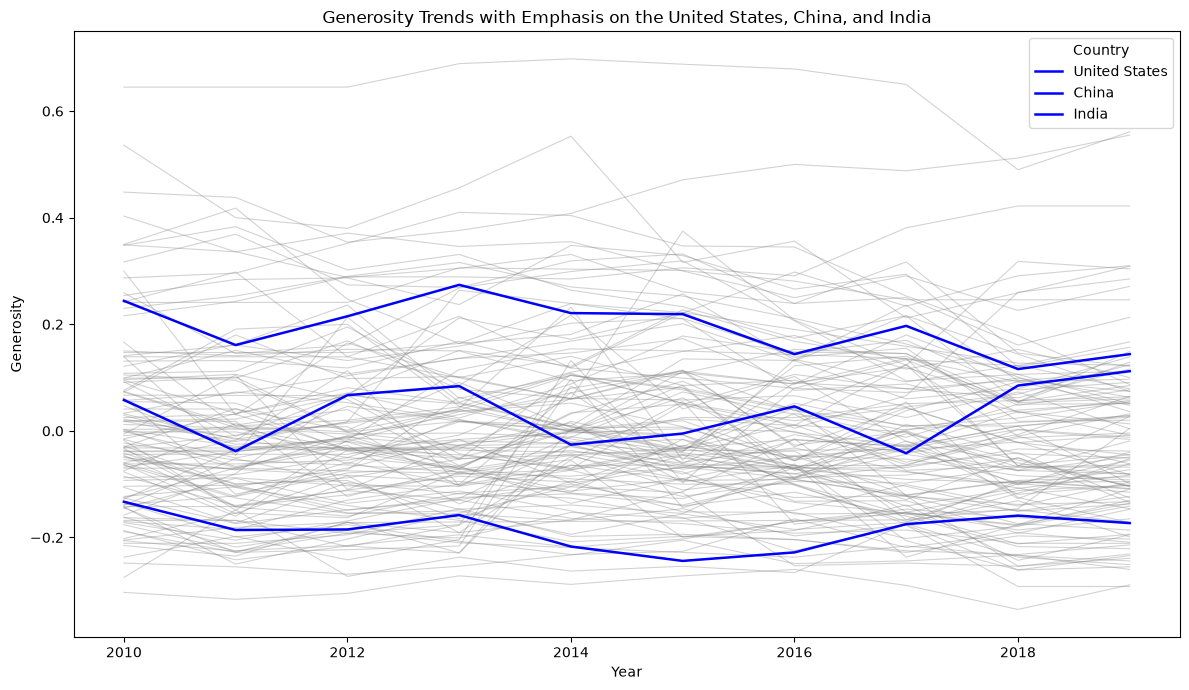

In [ ]:

selected_countries = [
    'United States',
    'China',
    'India'
]
report_sorted = report_df.sort_values(['Name', 'year'])

fig, ax = plt.subplots(figsize=(12, 7))


sns.lineplot(
    data=report_sorted,
    x='year',
    y='Generosity',
    units='Name',
    estimator=None,
    color='grey',
    linewidth=0.8,
    alpha=0.35,
    legend=False,
    ax=ax
)


for country in selected_countries:

    country_data = report_sorted[
        report_sorted['Name'] == country
    ]

    ax.plot(
        country_data['year'],
        country_data['Generosity'],
        color='blue',
        linewidth=1.8,
        label=country
    )


ax.set_title(
    'Generosity Trends with Emphasis on the United States, China, and India'
)

ax.set_xlabel('Year')
ax.set_ylabel('Generosity')

ax.legend(title='Country')

plt.tight_layout()
plt.show()

c.

In [26]:
selected_data = (
    report_df[
        report_df['Name'].isin(selected_countries)
    ]
    .dropna(subset=['year', 'Generosity'])
    .sort_values(['Name', 'year'])
)

generosity_summary = (
    selected_data
    .groupby('Name')
    .agg(
        first_year=('year', 'first'),
        last_year=('year', 'last'),
        first_generosity=('Generosity', 'first'),
        last_generosity=('Generosity', 'last')
    )
)

generosity_summary['change'] = (
    generosity_summary['last_generosity']
    - generosity_summary['first_generosity']
)

generosity_summary

,first_year,last_year,first_generosity,last_generosity,change
Name,,,,,
China,2010,2019,-0.133,-0.173,-0.040
India,2010,2019,0.058,0.112,0.054
United States,2010,2019,0.244,0.144,-0.100
